In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load the data
df = pd.read_csv('Dataset.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   destination_port             int64  
 1   flow_duration                int64  
 2   total_fwd_packets            int64  
 3   total_backward_packets       int64  
 4   total_length_of_fwd_packets  int64  
 5   total_length_of_bwd_packets  int64  
 6   fwd_packet_length_max        int64  
 7   fwd_packet_length_min        int64  
 8   fwd_packet_length_mean       float64
 9   fwd_packet_length_std        float64
 10  bwd_packet_length_max        int64  
 11  bwd_packet_length_min        int64  
 12  bwd_packet_length_mean       float64
 13  bwd_packet_length_std        float64
 14  flow_bytes/s                 float64
 15  flow_packets/s               float64
 16  flow_iat_mean                float64
 17  flow_iat_std                 float64
 18  flow_iat_max                 int64  
 19  flow_iat_mi

In [3]:
# Encode the label column

# Make a copy of the dataframe
df_encoded = df.copy()

# Create a label (category) encoder object
le = LabelEncoder()

# Fit and transform the 'label' column & assign the transformed values to a new column
df_encoded['label'] = le.fit_transform(df['label'])

# Print the mapping of original labels to encoded valuse
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping: ")
print(label_mapping)

# Display the modified DataFrame
print("/nEncoded DataFrame: ")
df_encoded.head()

Label Mapping: 
{'BENIGN': np.int64(0), 'Bot': np.int64(1), 'DDoS': np.int64(2), 'DoS GoldenEye': np.int64(3), 'DoS Hulk': np.int64(4), 'DoS Slowhttptest': np.int64(5), 'DoS slowloris': np.int64(6), 'FTP-Patator': np.int64(7), 'Heartbleed': np.int64(8), 'Infiltration': np.int64(9), 'PortScan': np.int64(10), 'SSH-Patator': np.int64(11), 'Web Attack � Brute Force': np.int64(12), 'Web Attack � Sql Injection': np.int64(13), 'Web Attack � XSS': np.int64(14)}
/nEncoded DataFrame: 


,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [4]:
# Binary encode

# Make a copy of the dataframe
df_bin = df.copy()

df_bin['label'] = df_bin['label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Display the modified DataFrame
print("/nEncoded DataFrame: ")
df_bin.head()

/nEncoded DataFrame: 


,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


Text(0.5, 1.0, 'No Attack vs Different Attacks')

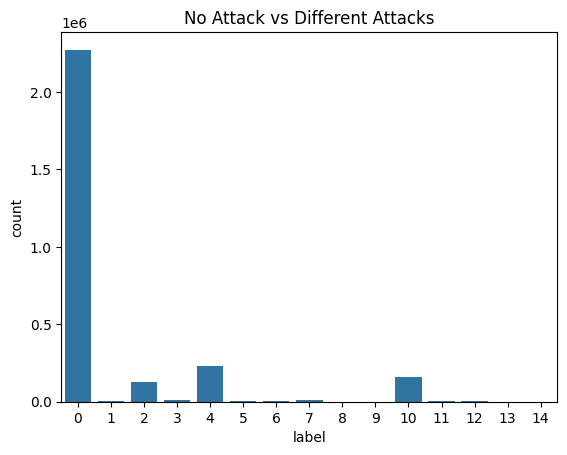

In [12]:
# Creating count plot
sns.countplot(x=df_encoded.label)
plt.title("No Attack vs Different Attacks")

Text(0.5, 1.0, 'No Attack vs Attack')

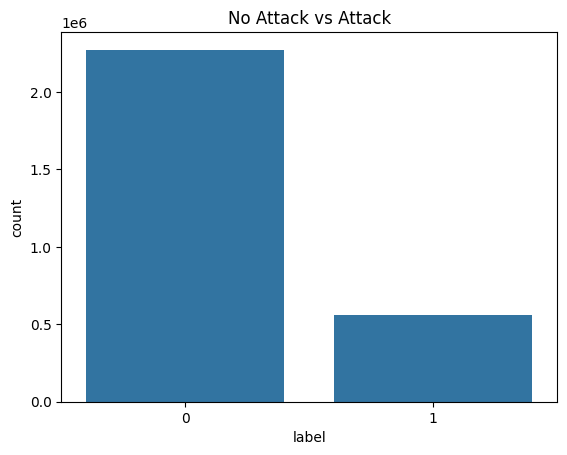

In [13]:
# Creating bin count plot
sns.countplot(x=df_bin.label)
plt.title("No Attack vs Attack")

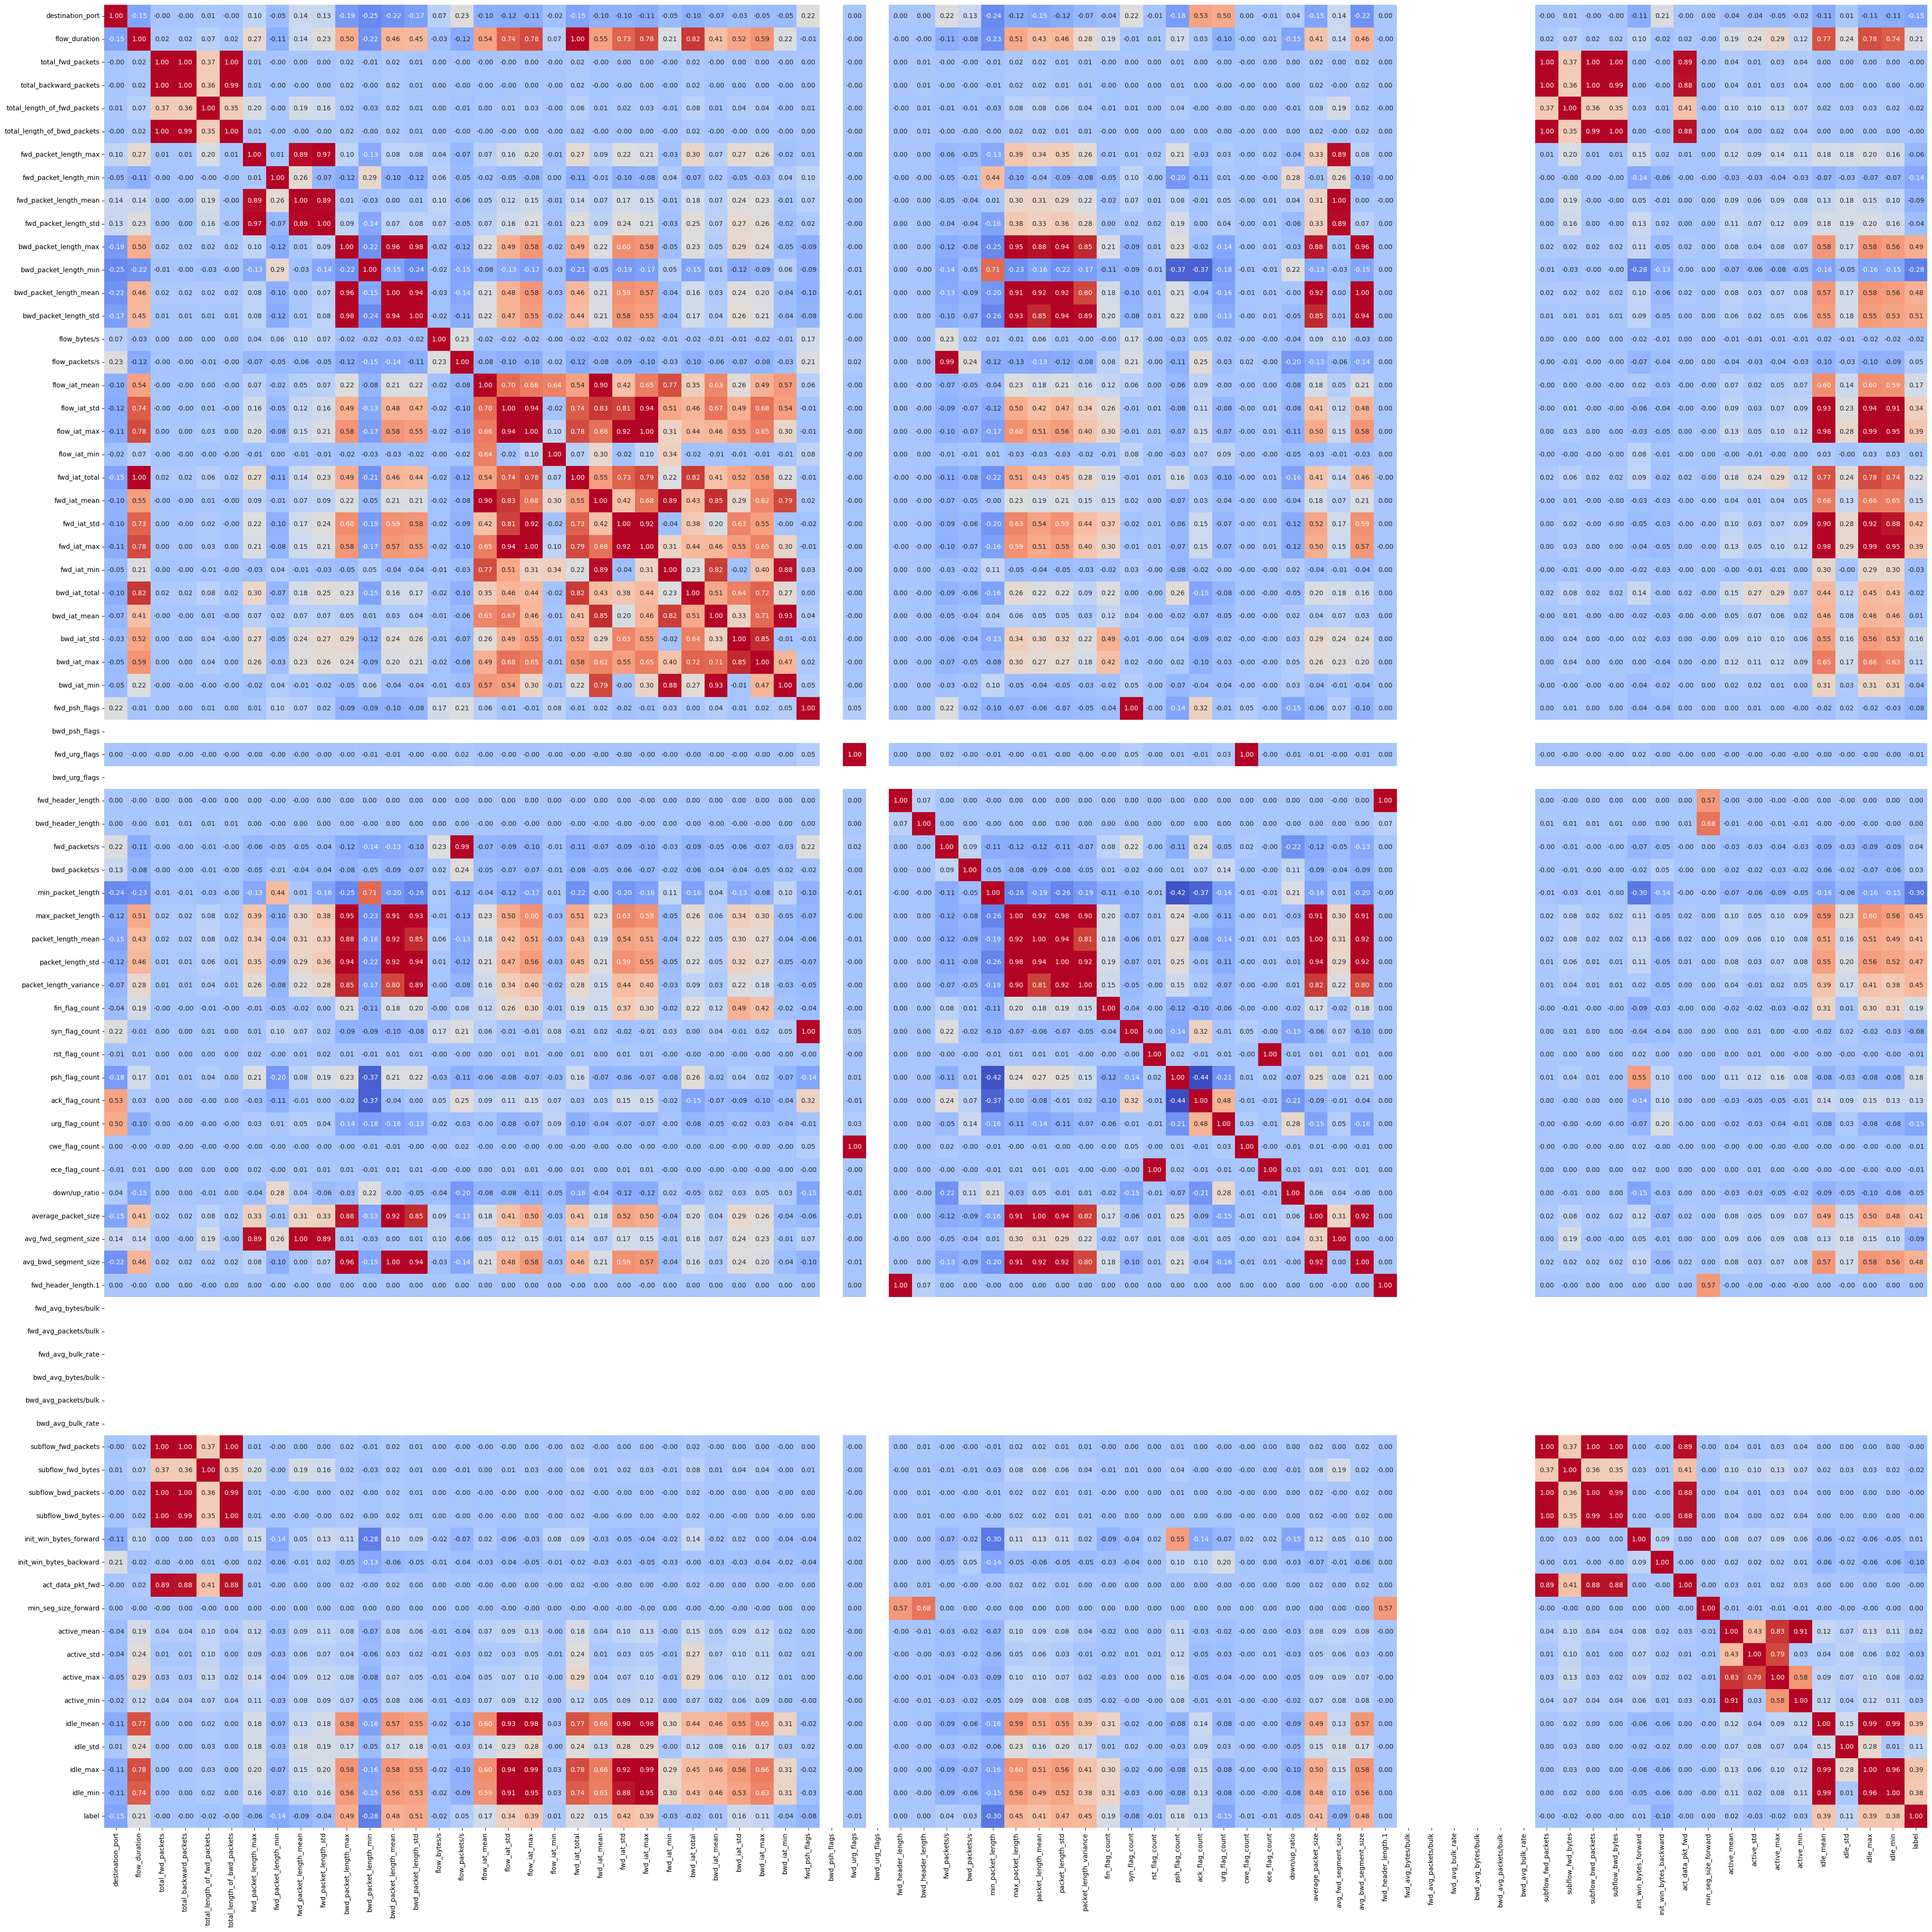

                             destination_port  flow_duration  \
destination_port                     1.000000      -0.151680   
flow_duration                       -0.151680       1.000000   
total_fwd_packets                   -0.004236       0.020857   
total_backward_packets              -0.003947       0.019670   
total_length_of_fwd_packets          0.011145       0.065456   
...                                       ...            ...   
idle_mean                           -0.112585       0.768034   
idle_std                             0.010399       0.243154   
idle_max                            -0.108185       0.779527   
idle_min                            -0.114614       0.738328   
label                               -0.148860       0.213864   

                             total_fwd_packets  total_backward_packets  \
destination_port                     -0.004236               -0.003947   
flow_duration                         0.020857                0.019670   
total_fwd

In [5]:
# Correlation
correlation_metrics = df_bin.corr(method='pearson')
fig = plt.figure(figsize= (50,50))
sns.heatmap(correlation_metrics,
            vmax = .9, 
            square = True,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            cbar=False) 
plt.show()
print(correlation_metrics)

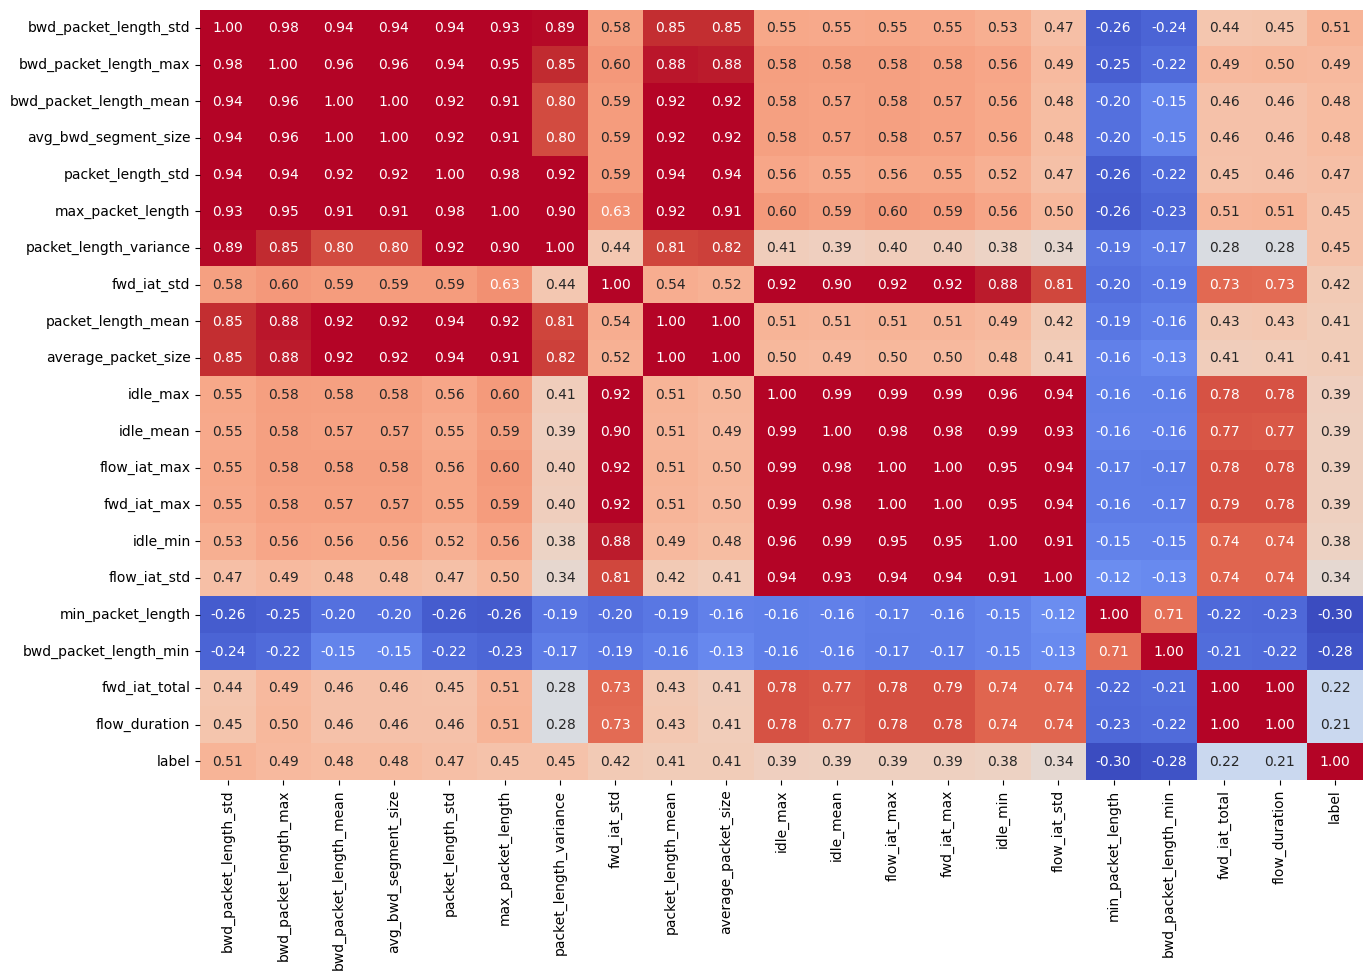

                        bwd_packet_length_std  bwd_packet_length_max  \
bwd_packet_length_std                1.000000               0.982778   
bwd_packet_length_max                0.982778               1.000000   
bwd_packet_length_mean               0.941526               0.959023   
avg_bwd_segment_size                 0.941526               0.959023   
packet_length_std                    0.942498               0.940083   
max_packet_length                    0.932756               0.948448   
packet_length_variance               0.891287               0.853215   
fwd_iat_std                          0.579521               0.603716   
packet_length_mean                   0.851543               0.881194   
average_packet_size                  0.850800               0.875633   
idle_max                             0.554927               0.582140   
idle_mean                            0.548077               0.577175   
flow_iat_max                         0.553239               0.57

In [19]:
# Top Features by corr
correlations = df_bin.corr(numeric_only=True)['label'].abs().sort_values(ascending=False)
top_features = correlations.drop('label').head(20).index.tolist()
subset_df = df_bin[top_features + ['label']]

correlation_top = subset_df.corr(method='pearson')
fig = plt.figure(figsize= (15,10))
sns.heatmap(correlation_top,
            vmax= 0.9,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            cbar=False) 
plt.show()
print(correlation_top)

In [21]:
corr_matrix = df_bin.corr(numeric_only=True)

# Threshold
threshold = 0.9
high_corr = corr_matrix.abs() > threshold
to_drop = set()

# Find columns which is greater than threshold
for i in range(len(high_corr.columns)):
    for j in range(i):
        if high_corr.iloc[i, j]:
            colName_i = high_corr.columns[i]
            colName_j = high_corr.columns[j]
            if colName_i not in to_drop and colName_j not in to_drop:
                to_drop.add(colName_j)

# Drop cols and store X in new df
df_bin_reduced = df_bin.drop(columns=to_drop)

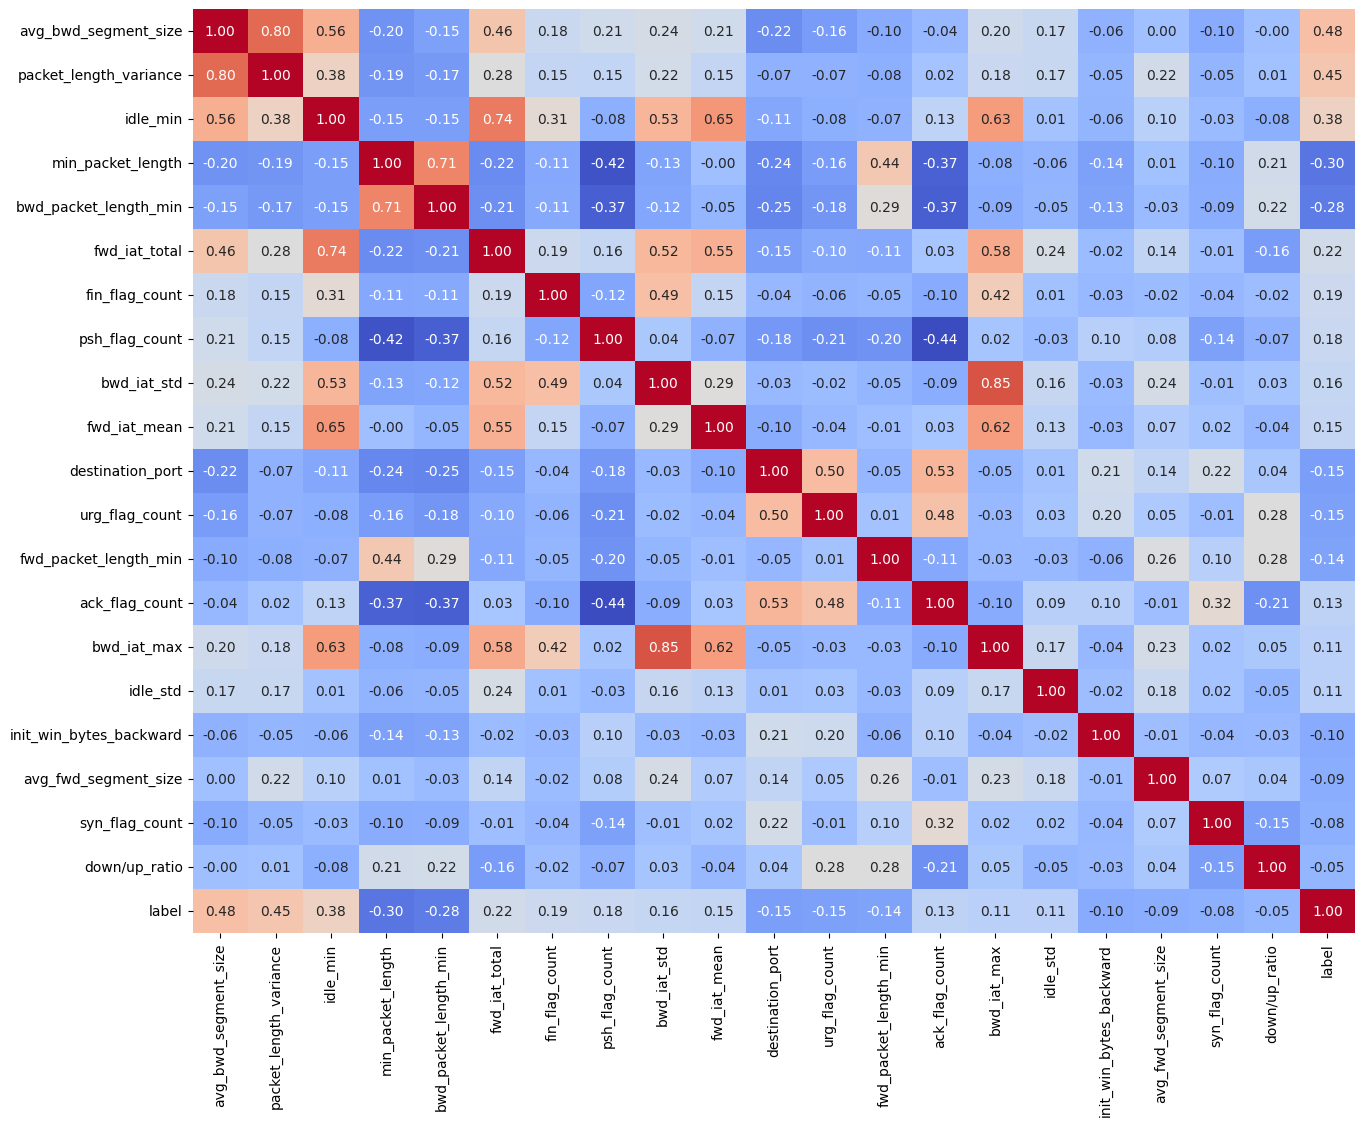

                         avg_bwd_segment_size  packet_length_variance  \
avg_bwd_segment_size                 1.000000                0.795014   
packet_length_variance               0.795014                1.000000   
idle_min                             0.555836                0.375488   
min_packet_length                   -0.202394               -0.189690   
bwd_packet_length_min               -0.145124               -0.170955   
fwd_iat_total                        0.458518                0.281272   
fin_flag_count                       0.182496                0.150811   
psh_flag_count                       0.211411                0.147856   
bwd_iat_std                          0.235775                0.217925   
fwd_iat_mean                         0.207041                0.153058   
destination_port                    -0.215817               -0.065570   
urg_flag_count                      -0.161340               -0.066273   
fwd_packet_length_min               -0.101162      

In [23]:
red_corr = df_bin_reduced.corr(numeric_only=True)['label'].abs().sort_values(ascending=False)
top_features_red = red_corr.drop('label').head(20).index.tolist()
subset_df_red = df_bin_reduced[top_features_red + ['label']]

correlation_top_red = subset_df_red.corr(method='pearson')
fig = plt.figure(figsize= (15,12))
sns.heatmap(correlation_top_red,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            cbar=False) 
plt.show()
print(correlation_top_red)

In [29]:
# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(df_bin_reduced)
dfbin_normalized = pd.DataFrame(normalized_data, columns=df_bin_reduced.columns)

In [ ]:
print(f"Min value of X after Normalization: {dfbin_normalized.min().min()}")
print(f"Max value of X after Normalization: {dfbin_normalized.max().max()}")

Min value of X after Normalization: 0.0
Max value of X after Normalization: 1.0000000000000002


In [31]:
X = dfbin_normalized.drop(columns=['label'])
y = dfbin_normalized['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=11, test_size = 0.2)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2264594, 48)
X_test shape: (566149, 48)
y_train shape: (2264594,)
y_test shape: (566149,)


In [32]:
X_train.to_csv("X_train_bin.csv", index=False)
X_test.to_csv("X_test_bin.csv", index=False)
y_train.to_csv("y_train_bin.csv", index=False)
y_test.to_csv("y_test_bin.csv", index=False)